# Dataset Exploration

Notebook generico per visualizzare dataset raw e output del progetto.

L'idea e semplice: cambi il `DATASET_PATH` nella cella di configurazione e puoi esplorare rapidamente `csv`, `parquet` o `xlsx`.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style='whitegrid')

project_root = Path.cwd()
if not (project_root / 'scripts').exists():
    project_root = project_root.parent

load_dotenv(project_root / '.env')
project_output_dir = Path(os.getenv('PROJECT_OUTPUT_DIR', '')) if os.getenv('PROJECT_OUTPUT_DIR') else None
local_output_dir = project_root / 'outputs' / 'local_preview'


## Configurazione

Scegli qui il file che vuoi esplorare. Puoi usare dati raw di BioCube oppure output prodotti da `selected_area_indicators.py`.

In [2]:
# Esempi utili:
# DATASET_PATH = Path('/Volumes/Archivio/biomap_thesis/data/biocube/Species/europe_species.parquet')
# DATASET_PATH = local_output_dir / 'selected_milano_area_monthly.xlsx'
# DATASET_PATH = local_output_dir / 'selected_milano_cells.parquet'

DATASET_PATH = local_output_dir / 'selected_milano_area_monthly.xlsx'
N_ROWS = 10
MAX_NUMERIC_PLOTS = 4
MAP_SAMPLE_SIZE = 5000
DATASET_PATH


PosixPath('/Users/simonemercolino/Desktop/Università/Tesi_BioMap/TCBiomap/tesi_bioanalyst_repo/outputs/local_preview/selected_milano_area_monthly.xlsx')

In [3]:
def read_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == '.csv':
        return pd.read_csv(path)
    if suffix == '.parquet':
        return pd.read_parquet(path)
    if suffix in {'.xlsx', '.xls'}:
        return pd.read_excel(path)
    raise ValueError(f'Formato non supportato: {suffix}')


df = read_dataset(DATASET_PATH)
if 'month' in df.columns:
    df['month'] = pd.to_datetime(df['month'])

print('path:', DATASET_PATH)
print('shape:', df.shape)
df.head(N_ROWS)


path: /Users/simonemercolino/Desktop/Università/Tesi_BioMap/TCBiomap/tesi_bioanalyst_repo/outputs/local_preview/selected_milano_area_monthly.xlsx
shape: (24, 6)


,month,temperature_mean_area_c,precipitation_mean_area_mm,cell_count_land,cells_with_species_records,species_count_observed_area
0,2018-01-01,5.880113,1.865078,16,3,2
1,2018-02-01,3.569927,1.888520,16,3,2
2,2018-03-01,7.174481,5.212458,16,6,4
3,2018-04-01,15.379239,4.151193,16,9,5
4,2018-05-01,18.174204,5.658120,16,9,5
5,2018-06-01,22.513562,2.697226,16,9,6
6,2018-07-01,24.942579,3.591881,16,7,6
7,2018-08-01,24.956467,3.361735,16,4,8
8,2018-09-01,20.544145,2.077650,16,7,6
9,2018-10-01,15.540622,6.303080,16,8,4


In [4]:
overview = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(dtype) for dtype in df.dtypes],
    'missing_values': [int(df[col].isna().sum()) for col in df.columns],
    'missing_pct': [round(float(df[col].isna().mean() * 100), 2) for col in df.columns],
})
overview


,column,dtype,missing_values,missing_pct
0,month,datetime64[us],0,0.0
1,temperature_mean_area_c,float64,0,0.0
2,precipitation_mean_area_mm,float64,0,0.0
3,cell_count_land,int64,0,0.0
4,cells_with_species_records,int64,0,0.0
5,species_count_observed_area,int64,0,0.0


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    display(df[numeric_cols].describe().T)
else:
    print('Nessuna colonna numerica disponibile.')


,count,mean,std,min,25%,50%,75%,max
temperature_mean_area_c,24.0,14.489632,7.704836,3.261914,6.947733,15.320291,21.036499,25.609562
precipitation_mean_area_mm,24.0,3.556549,2.263486,0.452848,2.030367,3.365296,4.593127,11.117402
cell_count_land,24.0,16.000000,0.000000,16.000000,16.000000,16.000000,16.000000,16.000000
cells_with_species_records,24.0,7.125000,2.659070,3.000000,5.000000,7.000000,9.000000,13.000000
species_count_observed_area,24.0,4.833333,1.711004,2.000000,4.000000,5.000000,6.000000,8.000000


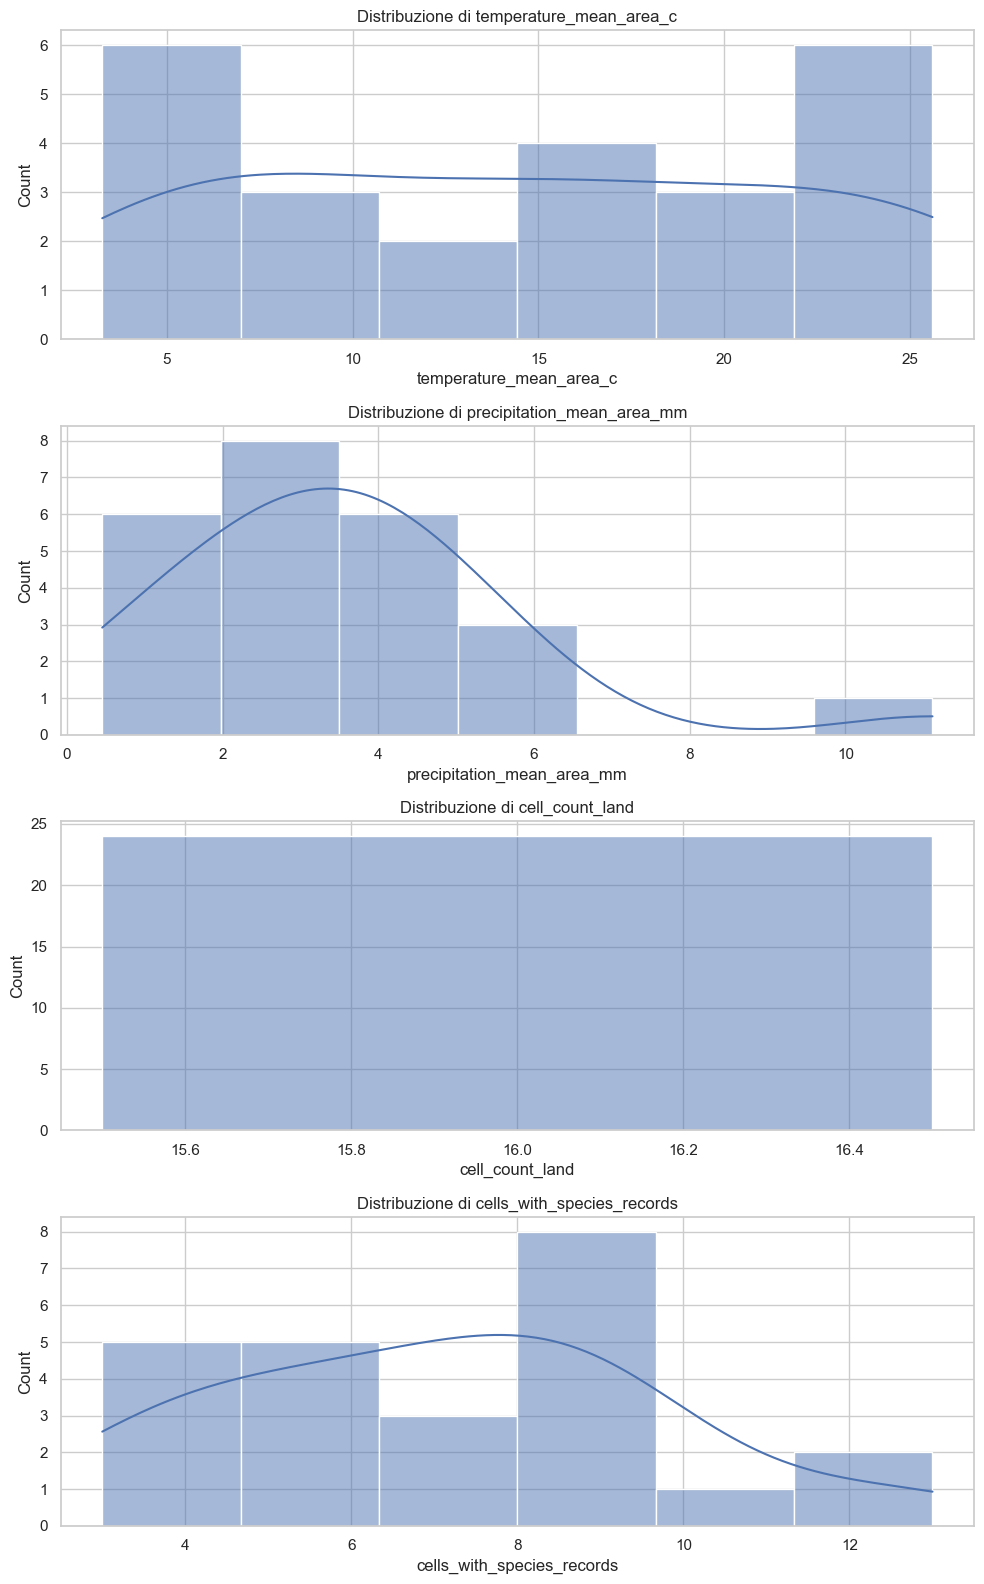

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
plot_cols = numeric_cols[:MAX_NUMERIC_PLOTS]

if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, column in zip(axes, plot_cols):
        sns.histplot(df[column].dropna(), ax=ax, kde=True)
        ax.set_title(f'Distribuzione di {column}')
    plt.tight_layout()
else:
    print('Nessuna colonna numerica da plottare.')


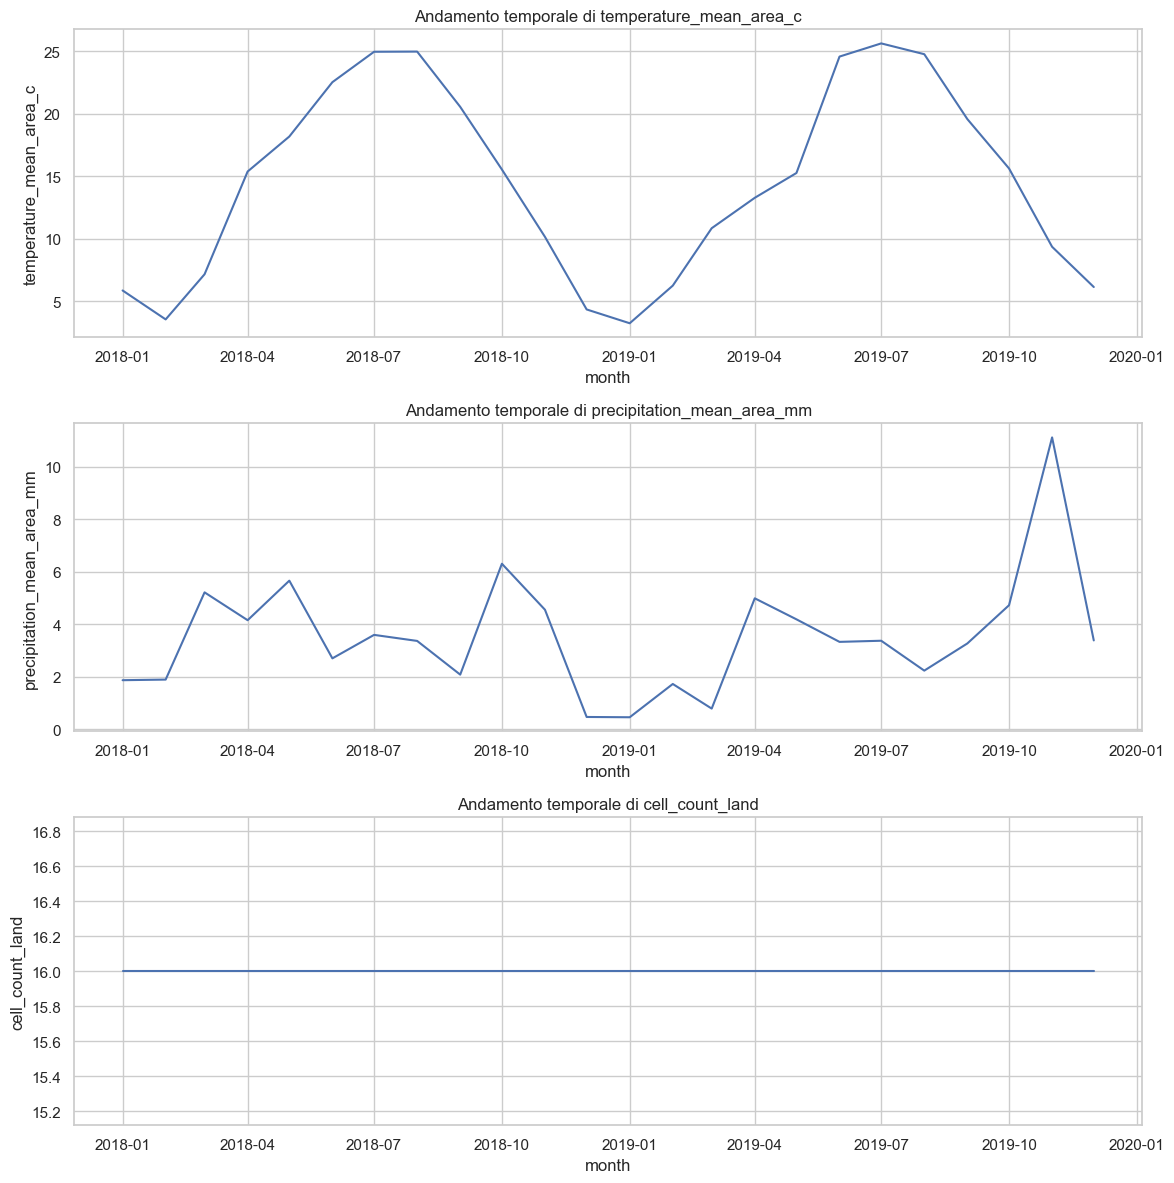

In [7]:
if 'month' in df.columns:
    value_cols = [col for col in df.select_dtypes(include='number').columns if col not in {'latitude', 'longitude'}]
    if value_cols:
        monthly = df.sort_values('month')
        fig, axes = plt.subplots(len(value_cols[:3]), 1, figsize=(12, 4 * len(value_cols[:3])))
        if len(value_cols[:3]) == 1:
            axes = [axes]
        for ax, column in zip(axes, value_cols[:3]):
            sns.lineplot(data=monthly, x='month', y=column, ax=ax)
            ax.set_title(f'Andamento temporale di {column}')
        plt.tight_layout()
    else:
        print('Nessuna misura numerica adatta al grafico temporale.')
else:
    print('Colonna month non presente.')


In [8]:
if {'latitude', 'longitude'}.issubset(df.columns):
    sample = df.sample(min(len(df), MAP_SAMPLE_SIZE), random_state=42)
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=sample, x='longitude', y='latitude', s=15, alpha=0.5)
    plt.title('Vista spaziale del dataset')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
else:
    print('Coordinate latitude/longitude non presenti.')


Coordinate latitude/longitude non presenti.
